# Panel local projections: CPI on xi x oil

This notebook is a notebook-first version of the panel local-projections workflow.

It is designed so you can:

- change horizons, lag lengths, and fixed effects interactively,
- start with `cpi_pct_change` on `xi_x_oil`,
- add country-year controls later by editing a small `panel_controls` list,
- optionally trim CPI outliers with an IQR rule before estimation,
- inspect the base panel before we promote the workflow into a full CLI pipeline.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [2]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

# Add future controls here. These are merged into the panel.
# Example:
# panel_controls = [
#     {
#         "name": "exchange_rate",
#         "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
#         "value_column": "log_diff",
#         "merge_keys": ["country", "period"],
#         "merge_key_columns": {"country": "country_code", "period": "quarter"},
#         "status_column": None,
#     }
# ]
panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    }
]

# Controls that actually enter the LP regression.
regression_controls = ["exchange_rate"]

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"exchange_rate": 3}
include_country_fe = True
include_year_fe = False
cov_type = "cluster_country"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_year_fe:", include_year_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'exchange_rate': 3}
include_country_fe: True
include_year_fe: False
cov_type: cluster_country
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate']
regression_controls: ['exchange_rate']


In [3]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,7522,80,1995,2022,23.625,1995-Q1,2022-Q4,94.025


In [4]:
panel_df.head()


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.003794,0.171750,0.147258
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.001324,0.209522,0.131988
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000229,0.179419,0.157769
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.005053,0.234092,0.181845
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.005188,0.200532,0.131072


In [5]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 7522


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.003794,0.171750,0.147258
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.001324,0.209522,0.131988
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000229,0.179419,0.157769
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.005053,0.234092,0.181845
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.005188,0.200532,0.131072


In [6]:
irf_df, coef_df, models = lp.fit_panel_local_projections(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_col="xi_x_oil",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_year_fe=include_year_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,0.271199,0.045574,5.950796,2.668415e-09,0.181877,0.360522,6399.0,80
1,1,xi_x_oil,0.262542,0.087069,3.015316,2.567118e-03,0.091889,0.433195,6399.0,80
2,2,xi_x_oil,0.165322,0.068695,2.406597,1.610191e-02,0.030682,0.299963,6399.0,80
3,3,xi_x_oil,0.150466,0.063211,2.380379,1.729482e-02,0.026575,0.274357,6399.0,80
4,4,xi_x_oil,0.088834,0.035159,2.526667,1.151505e-02,0.019925,0.157744,6399.0,80
5,5,xi_x_oil,-0.033650,0.025693,-1.309674,1.903060e-01,-0.084008,0.016708,6399.0,80
6,6,xi_x_oil,0.009883,0.034504,0.286427,7.745508e-01,-0.057743,0.077508,6399.0,80
7,7,xi_x_oil,0.081107,0.040968,1.979779,4.772842e-02,0.000812,0.161402,6399.0,80
8,8,xi_x_oil,0.001991,0.043839,0.045407,9.637825e-01,-0.083933,0.087914,6399.0,80
9,9,xi_x_oil,-0.066582,0.035801,-1.859804,6.291332e-02,-0.136750,0.003586,6399.0,80


In [7]:
coef_df.loc[coef_df["term"].isin(["xi_x_oil", "const"])].head(10)


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs
0,0,const,0.026065,0.001769,14.738632,3.640865e-49,0.022599,0.029531,6399.0
1,0,xi_x_oil,0.271199,0.045574,5.950796,2.668415e-09,0.181877,0.360522,6399.0
91,1,const,0.031328,0.002509,12.484547,9.065814e-36,0.026410,0.036246,6399.0
92,1,xi_x_oil,0.262542,0.087069,3.015316,2.567118e-03,0.091889,0.433195,6399.0
182,2,const,0.035536,0.002744,12.950243,2.342120e-38,0.030158,0.040914,6399.0
183,2,xi_x_oil,0.165322,0.068695,2.406597,1.610191e-02,0.030682,0.299963,6399.0
273,3,const,0.037100,0.002912,12.742193,3.445691e-37,0.031394,0.042807,6399.0
274,3,xi_x_oil,0.150466,0.063211,2.380379,1.729482e-02,0.026575,0.274357,6399.0
364,4,const,0.038075,0.002571,14.811525,1.234088e-49,0.033037,0.043114,6399.0
365,4,xi_x_oil,0.088834,0.035159,2.526667,1.151505e-02,0.019925,0.157744,6399.0


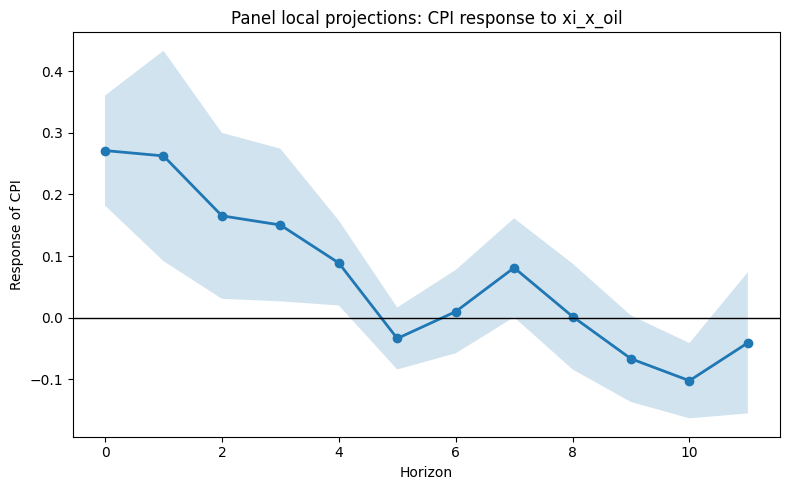

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, ax=ax)
plt.tight_layout()
plt.show()


In [9]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                             OLS Regression Results                             
Dep. Variable:     cpi_pct_change_lead0   R-squared:                       0.175
Model:                              OLS   Adj. R-squared:                  0.163
Method:                   Least Squares   F-statistic:                     1097.
Date:                  Sat, 28 Mar 2026   Prob (F-statistic):           1.58e-81
Time:                          23:05:40   Log-Likelihood:                 10198.
No. Observations:                  6399   AIC:                        -2.021e+04
Df Residuals:                      6308   BIC:                        -1.960e+04
Df Model:                            90                                         
Covariance Type:                cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 90, but rank is 11
  warnings.warn('covariance of constraints does not have full '
